# Batch Watermark Pipeline: Background Removal + OWLv2 + YOLO + SAM 2 + LaMa

This notebook is the cleaned-up batch pipeline version of `rnd_complete.ipynb`, now with a background-removal preprocessing stage.

The pipeline intentionally excludes GroundingDINO for now.

```text
input directory
  -> RMBG background removal
  -> white-background product image
  -> OWLv2 watermark classifier gate
  -> YOLO watermark detection
  -> SAM 2 segmentation masks
  -> LaMa inpainting
  -> structured output directory
```

The watermark pipeline runs on the **white-background image**, not the original image. This is useful for ecommerce product images because it standardizes the background before watermark detection and inpainting.

Use this only for images you own, control, or have permission to edit.


## 0. Runtime Check

Run this first to confirm the notebook sees a GPU. The full pipeline can run on CPU in theory, but SAM 2, RMBG, YOLO, and LaMa are intended to run on a CUDA GPU for practical batch processing.


In [1]:
# @title 0. Check GPU
import sys
import subprocess
from pathlib import Path

try:
    import torch
    print("CUDA available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("GPU:", torch.cuda.get_device_name(0))
        print("CUDA:", torch.version.cuda)
except Exception as exc:
    print("Torch is not installed yet:", exc)


CUDA available: True
GPU: Tesla T4
CUDA: 12.8


In [13]:
!apt-get update -qq
!apt-get install -y git-lfs
!git lfs install


!git clone https://huggingface.co/spaces/fancyfeast/joycaption-watermark-detection

!pip install ultralytics

^C
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
The following NEW packages will be installed:
  git-lfs
0 upgraded, 1 newly installed, 0 to remove and 134 not upgraded.
Need to get 3,544 kB of archives.
After this operation, 10.5 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy-updates/universe amd64 git-lfs amd64 3.0.2-1ubuntu0.3 [3,544 kB]
Fetched 3,544 kB in 1s (2,426 kB/s)
Selecting previously unselected package git-lfs.
(Reading database ... 122403 files and directories currently installed.)
Preparing to unpack .../git-lfs_3.0.2-1ubuntu0.3_amd64.deb ...
Unpacking git-lfs (3.0.2-1ubuntu0.3) ...
Setting up git-lfs (3.0.2-1ubuntu0.3) ...
Processing triggers for man-db (2.10.2-1) ...
Git LFS initialized.
Cloning into 'joycaption-watermark-detection'...
remote: Enumerating objects: 19, done.
remote: Total 19 (delta 0), reused 0 (delta 0), pack-reused 19 (from 1)
Receiving objects: 100% (19/19), 4.

## 1. Install Dependencies

This cell installs the shared runtime dependencies, clones Grounded-SAM-2 only for the SAM 2 code, downloads the SAM 2 checkpoint, and installs the BRIA RMBG background-removal requirements.

`transformers==4.39.3` is pinned because the RMBG reference code uses that version. The notebook checks later that both RMBG and OWLv2 imports are available after the install.


In [14]:
# @title 1. Install dependencies and set up SAM 2 + RMBG
import os
import subprocess
import sys
from pathlib import Path

SAM2_DIR = Path("/content/Grounded-SAM-2")
SAM2_CHECKPOINT_URL = "https://dl.fbaipublicfiles.com/segment_anything_2/092824/sam2.1_hiera_large.pt"
SAM2_CHECKPOINT = SAM2_DIR / "checkpoints" / "sam2.1_hiera_large.pt"
RMBG_REQUIREMENTS_URL = "https://huggingface.co/briaai/RMBG-1.4/resolve/main/requirements.txt"


def run_cmd(cmd, cwd=None, env=None):
    cmd = [str(part) for part in cmd]
    print("$", " ".join(cmd))
    completed = subprocess.run(
        cmd,
        cwd=cwd,
        env=env,
        text=True,
        capture_output=True,
    )
    if completed.stdout:
        print(completed.stdout)
    if completed.stderr:
        print(completed.stderr, file=sys.stderr)
    if completed.returncode != 0:
        raise subprocess.CalledProcessError(
            completed.returncode,
            cmd,
            output=completed.stdout,
            stderr=completed.stderr,
        )
    return completed


try:
    import torch
    print(f"torch {torch.__version__}; cuda available: {torch.cuda.is_available()}")
except Exception:
    run_cmd([sys.executable, "-m", "pip", "install", "-q", "torch", "torchvision", "torchaudio"])

run_cmd([sys.executable, "-m", "pip", "install", "-U", "pip", "setuptools", "wheel"])
run_cmd([
    sys.executable,
    "-m",
    "pip",
    "install",
    "-q",
    "accelerate",
    "ultralytics",
    "opencv-python-headless",
    "Pillow",
    "matplotlib",
    "pandas",
    "tqdm",
    "pycocotools",
])

if not (SAM2_DIR / ".git").exists():
    run_cmd(["git", "clone", "https://github.com/IDEA-Research/Grounded-SAM-2.git", SAM2_DIR])
else:
    run_cmd(["git", "-C", SAM2_DIR, "pull", "--ff-only"])

sam2_env = os.environ.copy()
sam2_env["SAM2_BUILD_CUDA"] = "0"
run_cmd([sys.executable, "-m", "pip", "install", "-q", "-e", ".[notebooks]"], cwd=SAM2_DIR, env=sam2_env)

SAM2_CHECKPOINT.parent.mkdir(parents=True, exist_ok=True)
if not SAM2_CHECKPOINT.exists():
    run_cmd(["wget", "-nc", "-P", SAM2_CHECKPOINT.parent, SAM2_CHECKPOINT_URL])

# RMBG reference setup. Install this after SAM 2 so the transformer version remains pinned.
run_cmd([sys.executable, "-m", "pip", "install", "-q", "-r", RMBG_REQUIREMENTS_URL])
run_cmd([sys.executable, "-m", "pip", "install", "-q", "transformers==4.39.3", "huggingface_hub", "scikit-image"])

print("SAM 2 setup ready:", SAM2_DIR)
print("SAM 2 checkpoint:", SAM2_CHECKPOINT)


torch 2.11.0+cu128; cuda available: True
$ /usr/bin/python3 -m pip install -U pip setuptools wheel


KeyboardInterrupt: 

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 2. Configure Paths and Thresholds

Edit this cell for your run. The important paths are:

- `INPUT_DIR`: root directory containing category subfolders, for example `/content/drive/MyDrive/images`.
- `OUTPUT_DIR`: directory where generated artifacts are saved. The notebook mirrors the input category folders under this output root.
- `CLASSIFIER_WEIGHTS`: OWLv2 classifier weights.
- `YOLO_WEIGHTS`: trained YOLO watermark detector weights.

Background removal is enabled by default. The pipeline will save a white-background product image and run all watermark steps on that white-background image.


In [15]:
# @title 2. Configure input, output, and model paths
from pathlib import Path

# Root folder containing category subfolders. Supports jpg, jpeg, png, webp, bmp, tif, tiff.
INPUT_DIR = Path("/content/drive/MyDrive/infringement_project/Product Images with Watermarks")

# Results are written here.
OUTPUT_DIR = Path("/content/drive/MyDrive/infringement_project/Product Images with Watermarks/watermark_batch_outputs")

# Model weights from your current R&D notebook.
# Change these to your uploaded, Google Drive, or downloaded paths.
CLASSIFIER_WEIGHTS = Path("/content/far5y1y5-8000.pt")
YOLO_WEIGHTS = Path("/content/yolo11x-train28-best.pt")

# Background removal controls.
RUN_BACKGROUND_REMOVAL = True
BG_MODEL_NAME = "briaai/RMBG-1.4"
BG_MODEL_INPUT_SIZE = [1024, 1024]
BG_OVERWRITE_EXISTING = False
SAVE_TRANSPARENT_BG_DEBUG = False

# SAM 2 config/checkpoint.
SAM2_DIR = Path("/content/Grounded-SAM-2")
SAM2_CHECKPOINT = SAM2_DIR / "checkpoints" / "sam2.1_hiera_large.pt"
SAM2_CONFIG = "configs/sam2.1/sam2.1_hiera_l.yaml"

# Detection controls.
YOLO_CONF = 0.25
YOLO_IOU = 0.50
YOLO_IMGSZ = 1024
YOLO_AUGMENT = True

# Conservative classifier gate.
# Skip only when the classifier is very confident the white-background image is clean.
SKIP_CONFIDENTLY_CLEAN = True
CLEAN_WATERMARK_PROB_THRESHOLD = 0.10
CLEAN_NOT_WATERMARKED_PROB_THRESHOLD = 0.90

RUN_CLASSIFIER_GATE = False

# Batch controls.
RECURSIVE_INPUT = True
RUN_LAMA = True
LAMA_DILATE_PX = 2
LAMA_MASK_THRESHOLD = 127
COPY_WATERMARK_INPUT_FOR_CLEAN_IMAGES = True

INPUT_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("Input directory:", INPUT_DIR)
print("Output directory:", OUTPUT_DIR)
print("Background removal enabled:", RUN_BACKGROUND_REMOVAL)
print("Classifier weights:", CLASSIFIER_WEIGHTS)
print("YOLO weights:", YOLO_WEIGHTS)
print("RUN_CLASSIFIER_GATE: ", RUN_CLASSIFIER_GATE)



Input directory: /content/drive/MyDrive/infringement_project/Product Images with Watermarks
Output directory: /content/drive/MyDrive/infringement_project/Product Images with Watermarks/watermark_batch_outputs
Background removal enabled: True
Classifier weights: /content/far5y1y5-8000.pt
YOLO weights: /content/yolo11x-train28-best.pt
RUN_CLASSIFIER_GATE:  False


## 3. Shared Imports and Helpers

These helpers keep output paths stable and safe for batch runs. Each input image gets its own output folder inside its category path. A readable slug plus a short hash prevents duplicate filenames from colliding.


In [17]:
# @title 3. Shared imports and filesystem helpers
import gc
import hashlib
import json
import os
import re
import shutil
import sys
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from PIL import Image, ImageFilter, ImageOps
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch import nn
import torchvision.transforms.functional as TVF
from torchvision.transforms.functional import normalize
from transformers import AutoModelForImageSegmentation, Owlv2VisionModel
from ultralytics import YOLO

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".webp", ".bmp", ".tif", ".tiff"}


def write_json(path, payload):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)


def read_json(path):
    with Path(path).open("r", encoding="utf-8") as f:
        return json.load(f)


def relative_image_path(image_path, input_root):
    image_path = Path(image_path)
    input_root = Path(input_root)
    try:
        return image_path.relative_to(input_root)
    except ValueError:
        return Path(image_path.name)


def category_relative_parent(image_path, input_root):
    rel = relative_image_path(image_path, input_root)
    parent = rel.parent
    if str(parent) == ".":
        return Path("_uncategorized")
    return parent


def category_name(image_path, input_root):
    rel = relative_image_path(image_path, input_root)
    if len(rel.parts) > 1:
        return rel.parts[0]
    return "_uncategorized"


def safe_image_id(image_path, input_root):
    image_path = Path(image_path)
    rel = relative_image_path(image_path, input_root)
    stem = Path(rel).stem or image_path.stem
    slug = re.sub(r"[^a-zA-Z0-9_.-]+", "_", stem).strip("_")
    digest = hashlib.sha1(str(rel).encode("utf-8")).hexdigest()[:8]
    return f"{slug}_{digest}" if slug else digest


def image_output_dir_for(image_path, output_root, input_root=INPUT_DIR):
    image_id = safe_image_id(image_path, input_root)
    return Path(output_root) / category_relative_parent(image_path, input_root) / image_id

def iter_image_paths(input_dir, recursive=False):
    input_dir = Path(input_dir)
    pattern = "**/*" if recursive else "*"
    paths = [p for p in input_dir.glob(pattern) if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS]
    return sorted(paths)


def ensure_dirs(image_output_dir):
    image_output_dir = Path(image_output_dir)
    dirs = {
        "root": image_output_dir,
        "background_removed": image_output_dir / "background_removed",
        "detections": image_output_dir / "detections",
        "masks": image_output_dir / "masks",
        "annotated": image_output_dir / "annotated",
        "inpainted": image_output_dir / "inpainted",
    }
    for path in dirs.values():
        path.mkdir(parents=True, exist_ok=True)
    return dirs


def save_rgb_image(image, output_path, **save_kwargs):
    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)
    image.convert("RGB").save(output_path, **save_kwargs)
    return output_path


def copy_path(src, dst):
    src = Path(src)
    dst = Path(dst)
    dst.parent.mkdir(parents=True, exist_ok=True)
    if src.resolve() != dst.resolve():
        shutil.copy2(src, dst)
    return dst


def make_empty_mask(image):
    return np.zeros((image.height, image.width), dtype=np.uint8)


def release_cuda():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.ipc_collect()


print("Using device:", DEVICE)
print("Transformers imports available: AutoModelForImageSegmentation, Owlv2VisionModel")


Using device: cuda
Transformers imports available: AutoModelForImageSegmentation, Owlv2VisionModel


## 4. Background Removal Stage

This stage is based on `bg_removal.md`.

For each source image it saves:

```text
<category>/<image_id>/source_original.png
<category>/<image_id>/background_removed/foreground_mask.png
<category>/<image_id>/background_removed/white_background.png
```

Only `white_background.png` is passed to OWLv2, YOLO, SAM 2, and LaMa. The foreground mask is kept so you can audit the background-removal quality later.


In [18]:
# @title 4. RMBG background removal helpers

def load_background_removal_model():
    model = AutoModelForImageSegmentation.from_pretrained(
        BG_MODEL_NAME,
        trust_remote_code=True,
    )
    model.to(DEVICE)
    model.eval()
    return model


def preprocess_background_image(image: np.ndarray, model_input_size: list) -> torch.Tensor:
    if len(image.shape) < 3:
        image = image[:, :, np.newaxis]

    # Grayscale to RGB.
    if image.shape[2] == 1:
        image = np.repeat(image, 3, axis=2)

    # RGBA to RGB.
    if image.shape[2] == 4:
        image = image[:, :, :3]

    image_tensor = torch.tensor(image, dtype=torch.float32).permute(2, 0, 1)
    image_tensor = image_tensor.unsqueeze(0)
    image_tensor = F.interpolate(
        image_tensor,
        size=model_input_size,
        mode="bilinear",
        align_corners=False,
    )
    image_tensor = image_tensor / 255.0
    image_tensor = normalize(
        image_tensor,
        mean=[0.5, 0.5, 0.5],
        std=[1.0, 1.0, 1.0],
    )
    return image_tensor


def get_background_model_output_tensor(model_output):
    if isinstance(model_output, torch.Tensor):
        return model_output

    if isinstance(model_output, (list, tuple)):
        output = model_output[0]
        if isinstance(output, (list, tuple)):
            output = output[0]
        return output

    if hasattr(model_output, "logits"):
        return model_output.logits

    raise TypeError(f"Unsupported model output type: {type(model_output)}")


def postprocess_background_mask(result: torch.Tensor, original_size: tuple) -> np.ndarray:
    result = result.detach()

    # Remove extra dimensions safely. RMBG outputs can differ slightly across wrappers.
    while result.ndim > 4:
        result = result.squeeze(0)

    if result.ndim == 4:
        result = result[0, 0]
    elif result.ndim == 3:
        result = result[0]
    elif result.ndim == 2:
        pass
    else:
        raise ValueError(f"Unexpected result shape: {result.shape}")

    result = result.unsqueeze(0).unsqueeze(0)
    result = F.interpolate(
        result,
        size=original_size,
        mode="bilinear",
        align_corners=False,
    )
    result = result.squeeze()

    max_val = torch.max(result)
    min_val = torch.min(result)
    result = (result - min_val) / (max_val - min_val + 1e-8)
    return (result * 255).cpu().numpy().astype(np.uint8)


def composite_on_white(original_rgb: Image.Image, mask: np.ndarray) -> tuple[Image.Image, Image.Image]:
    mask_image = Image.fromarray(mask).convert("L")
    transparent_image = original_rgb.copy()
    transparent_image.putalpha(mask_image)

    white_background = Image.new("RGBA", transparent_image.size, (255, 255, 255, 255))
    white_background.alpha_composite(transparent_image)
    return white_background.convert("RGB"), mask_image


def build_source_pipeline_item(image_path: Path, output_root: Path) -> dict:
    image_id = safe_image_id(image_path, INPUT_DIR)
    dirs = ensure_dirs(image_output_dir_for(image_path, output_root))

    source_image = Image.open(image_path)
    source_image = ImageOps.exif_transpose(source_image).convert("RGB")
    source_original_path = dirs["root"] / "source_original.png"
    save_rgb_image(source_image, source_original_path)

    return {
        "image_id": image_id,
        "source_image_path": str(image_path),
        "relative_image_path": str(relative_image_path(image_path, INPUT_DIR)),
        "relative_parent": str(category_relative_parent(image_path, INPUT_DIR)),
        "category": category_name(image_path, INPUT_DIR),
        "source_original_path": str(source_original_path),
        "watermark_input_image_path": str(source_original_path),
        "background_removed_image_path": None,
        "foreground_mask_path": None,
        "background_removal_status": "not_run",
        "background_removal_error": None,
    }


def process_single_background_removal(image_path: Path, model, output_root: Path) -> dict:
    image_id = safe_image_id(image_path, INPUT_DIR)
    dirs = ensure_dirs(image_output_dir_for(image_path, output_root))

    source_original_path = dirs["root"] / "source_original.png"
    white_bg_path = dirs["background_removed"] / "white_background.png"
    foreground_mask_path = dirs["background_removed"] / "foreground_mask.png"
    transparent_debug_path = dirs["background_removed"] / "transparent_debug.png"

    if (
        not BG_OVERWRITE_EXISTING
        and source_original_path.exists()
        and white_bg_path.exists()
        and foreground_mask_path.exists()
    ):
        return {
            "image_id": image_id,
            "source_image_path": str(image_path),
            "relative_image_path": str(relative_image_path(image_path, INPUT_DIR)),
            "relative_parent": str(category_relative_parent(image_path, INPUT_DIR)),
            "category": category_name(image_path, INPUT_DIR),
            "source_original_path": str(source_original_path),
            "watermark_input_image_path": str(white_bg_path),
            "background_removed_image_path": str(white_bg_path),
            "foreground_mask_path": str(foreground_mask_path),
            "background_removal_status": "cached",
            "background_removal_error": None,
        }

    original = Image.open(image_path)
    original = ImageOps.exif_transpose(original).convert("RGB")
    save_rgb_image(original, source_original_path)

    original_np = np.array(original)
    original_size = original_np.shape[:2]
    input_tensor = preprocess_background_image(original_np, BG_MODEL_INPUT_SIZE).to(DEVICE)

    with torch.no_grad():
        model_output = model(input_tensor)

    output_tensor = get_background_model_output_tensor(model_output)
    mask = postprocess_background_mask(output_tensor, original_size)
    white_background, mask_image = composite_on_white(original, mask)

    mask_image.save(foreground_mask_path)
    white_background.save(white_bg_path)

    if SAVE_TRANSPARENT_BG_DEBUG:
        transparent_image = original.copy()
        transparent_image.putalpha(mask_image)
        transparent_image.save(transparent_debug_path)

    return {
        "image_id": image_id,
        "source_image_path": str(image_path),
        "relative_image_path": str(relative_image_path(image_path, INPUT_DIR)),
        "relative_parent": str(category_relative_parent(image_path, INPUT_DIR)),
        "category": category_name(image_path, INPUT_DIR),
        "source_original_path": str(source_original_path),
        "watermark_input_image_path": str(white_bg_path),
        "background_removed_image_path": str(white_bg_path),
        "foreground_mask_path": str(foreground_mask_path),
        "background_removal_status": "processed",
        "background_removal_error": None,
    }


def run_background_removal_stage(image_paths, output_root: Path) -> list[dict]:
    if not RUN_BACKGROUND_REMOVAL:
        print("Background removal disabled. Using source images as watermark inputs.")
        return [build_source_pipeline_item(path, output_root) for path in image_paths]

    model = None
    items = []
    try:
        print("Loading RMBG background-removal model...")
        model = load_background_removal_model()

        for image_path in tqdm(image_paths, desc="Removing backgrounds"):
            try:
                items.append(process_single_background_removal(image_path, model, output_root))
            except Exception as exc:
                image_id = safe_image_id(image_path, INPUT_DIR)
                dirs = ensure_dirs(image_output_dir_for(image_path, output_root))
                error_item = {
                    "image_id": image_id,
                    "source_image_path": str(image_path),
                    "relative_image_path": str(relative_image_path(image_path, INPUT_DIR)),
                    "relative_parent": str(category_relative_parent(image_path, INPUT_DIR)),
                    "category": category_name(image_path, INPUT_DIR),
                    "source_original_path": None,
                    "watermark_input_image_path": None,
                    "background_removed_image_path": None,
                    "foreground_mask_path": None,
                    "background_removal_status": "error",
                    "background_removal_error": str(exc),
                }
                write_json(
                    dirs["detections"] / "pipeline_result.json",
                    {
                        "provider": "background_removal_yolo_sam2_lama_batch",
                        "image_id": image_id,
                        "source_image_path": str(image_path),
                        "status": "background_removal_error",
                        "error": str(exc),
                    },
                )
                items.append(error_item)
                print(f"ERROR during background removal for {image_path}: {exc}")
    finally:
        if model is not None:
            del model
        release_cuda()

    return items


## 5. OWLv2 Classifier Gate

The classifier only decides whether an image is likely watermarked. It does not locate the watermark.

The gate is conservative: it skips downstream work only when the image is very confidently clean. If the classifier is uncertain, the pipeline still runs YOLO and SAM 2.


In [19]:
# @title 5. OWLv2 classifier gate
class DetectorModelOwl(nn.Module):
    def __init__(self, model_path: str, dropout: float = 0.0, n_hidden: int = 768):
        super().__init__()
        owl = Owlv2VisionModel.from_pretrained(model_path)
        assert isinstance(owl, Owlv2VisionModel)

        self.owl = owl
        self.owl.requires_grad_(False)

        self.dropout1 = nn.Dropout(dropout)
        self.ln1 = nn.LayerNorm(n_hidden, eps=1e-5)
        self.linear1 = nn.Linear(n_hidden, n_hidden * 2)
        self.act1 = nn.GELU()

        self.dropout2 = nn.Dropout(dropout)
        self.ln2 = nn.LayerNorm(n_hidden * 2, eps=1e-5)
        self.linear2 = nn.Linear(n_hidden * 2, 2)

    def forward(self, pixel_values: torch.Tensor, labels: torch.Tensor | None = None):
        outputs = self.owl(pixel_values=pixel_values, output_hidden_states=True)
        x = outputs.last_hidden_state

        x = self.dropout1(x)
        x = self.ln1(x)
        x = self.linear1(x)
        x = self.act1(x)
        x = self.dropout2(x)

        # Original R&D model uses max pooling over tokens.
        x, _ = x.max(dim=1)

        x = self.ln2(x)
        x = self.linear2(x)

        if labels is not None:
            loss = F.cross_entropy(x, labels)
            return x, loss

        return (x,)


def preprocess_for_owl(image: Image.Image) -> torch.Tensor:
    image = image.convert("RGB")
    big_side = max(image.size)
    padded = Image.new("RGB", (big_side, big_side), (128, 128, 128))
    padded.paste(image, (0, 0))

    bicubic = getattr(getattr(Image, "Resampling", Image), "BICUBIC")
    resized = padded.resize((960, 960), bicubic)
    tensor = TVF.pil_to_tensor(resized).float() / 255.0
    tensor = TVF.normalize(
        tensor,
        mean=[0.48145466, 0.4578275, 0.40821073],
        std=[0.26862954, 0.26130258, 0.27577711],
    )
    return tensor.unsqueeze(0)


def load_classifier(weights_path: Path = CLASSIFIER_WEIGHTS) -> DetectorModelOwl:
    weights_path = Path(weights_path)
    if not weights_path.exists():
        raise FileNotFoundError(f"Classifier weights not found: {weights_path}")

    model = DetectorModelOwl(
        model_path="google/owlv2-base-patch16-ensemble",
        dropout=0.0,
    )

    state_dict = torch.load(weights_path, map_location=DEVICE)
    if isinstance(state_dict, dict) and "state_dict" in state_dict:
        state_dict = state_dict["state_dict"]
    if isinstance(state_dict, dict) and any(key.startswith("module.") for key in state_dict):
        state_dict = {key.removeprefix("module."): value for key, value in state_dict.items()}

    model.load_state_dict(state_dict)
    model.to(DEVICE)
    model.eval()
    return model


@torch.no_grad()
def classify_watermark(image: Image.Image, model: DetectorModelOwl) -> dict:
    input_tensor = preprocess_for_owl(image).to(DEVICE)
    logits, = model(input_tensor)
    probs = F.softmax(logits, dim=1)[0]

    prob_not_watermarked = float(probs[0].detach().cpu())
    prob_watermarked = float(probs[1].detach().cpu())
    predicted_class = int(torch.argmax(probs).detach().cpu())

    return {
        "label": "Watermarked" if predicted_class == 1 else "Not Watermarked",
        "is_watermarked": predicted_class == 1,
        "prob_not_watermarked": prob_not_watermarked,
        "prob_watermarked": prob_watermarked,
    }


def should_skip_as_clean(classifier_result: dict | None) -> bool:
    if not RUN_CLASSIFIER_GATE or not SKIP_CONFIDENTLY_CLEAN or classifier_result is None:
        return False
    return (
        classifier_result["prob_watermarked"] < CLEAN_WATERMARK_PROB_THRESHOLD
        and classifier_result["prob_not_watermarked"] > CLEAN_NOT_WATERMARKED_PROB_THRESHOLD
    )


## 6. YOLO Detection and SAM 2 Segmentation

YOLO finds candidate watermark boxes. SAM 2 turns those boxes into pixel masks.

The combined mask is what LaMa will inpaint. Individual masks and the annotated image are kept for debugging and quality review.


In [20]:
# @title 6. YOLO detection and SAM 2 segmentation
sys.path.append(str(SAM2_DIR))
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor


def load_yolo(weights_path: Path = YOLO_WEIGHTS) -> YOLO:
    weights_path = Path(weights_path)
    if not weights_path.exists():
        raise FileNotFoundError(f"YOLO weights not found: {weights_path}")
    return YOLO(str(weights_path))


def yolo_class_name(yolo_model: YOLO, cls_id: int) -> str:
    names = yolo_model.names
    if isinstance(names, dict):
        return names.get(cls_id, str(cls_id))
    if isinstance(names, list) and 0 <= cls_id < len(names):
        return names[cls_id]
    return str(cls_id)


def detect_watermarks_yolo(image: Image.Image, yolo_model: YOLO) -> list[dict]:
    results = yolo_model(
        image.convert("RGB"),
        imgsz=YOLO_IMGSZ,
        conf=YOLO_CONF,
        iou=YOLO_IOU,
        augment=YOLO_AUGMENT,
        verbose=False,
    )
    result = results[0]
    boxes = []

    if result.boxes is None:
        return boxes

    for box in result.boxes:
        xyxy = [float(value) for value in box.xyxy[0].detach().cpu().tolist()]
        score = float(box.conf[0].detach().cpu())
        cls_id = int(box.cls[0].detach().cpu())
        boxes.append(
            {
                "class_id": cls_id,
                "class_name": yolo_class_name(yolo_model, cls_id),
                "confidence": score,
                "xyxy": xyxy,
            }
        )

    return boxes


def load_sam2_predictor(
    checkpoint_path: Path = SAM2_CHECKPOINT,
    config_path: str = SAM2_CONFIG,
) -> SAM2ImagePredictor:
    checkpoint_path = Path(checkpoint_path)
    if not checkpoint_path.exists():
        raise FileNotFoundError(f"SAM 2 checkpoint not found: {checkpoint_path}")

    cwd = Path.cwd()
    os.chdir(SAM2_DIR)
    try:
        sam2_model = build_sam2(
            config_file=config_path,
            ckpt_path=str(checkpoint_path),
            device=DEVICE,
        )
    finally:
        os.chdir(cwd)

    return SAM2ImagePredictor(sam2_model)


def run_sam2_on_yolo_boxes(
    image: Image.Image,
    boxes: list[dict],
    predictor: SAM2ImagePredictor,
) -> tuple[np.ndarray, np.ndarray]:
    if len(boxes) == 0:
        return np.zeros((0, image.height, image.width), dtype=np.uint8), np.array([], dtype=np.float32)

    image_np = np.array(image.convert("RGB"))
    predictor.set_image(image_np)
    input_boxes = np.array([box["xyxy"] for box in boxes], dtype=np.float32)

    masks, sam_scores, _ = predictor.predict(
        point_coords=None,
        point_labels=None,
        box=input_boxes,
        multimask_output=False,
    )

    if masks.ndim == 2:
        masks = masks[None, :, :]
    if masks.ndim == 4:
        masks = masks.squeeze(1)

    masks = masks.astype(np.uint8)
    sam_scores = np.array(sam_scores).reshape(-1)
    return masks, sam_scores


def create_combined_mask(masks: np.ndarray, image: Image.Image) -> np.ndarray:
    if masks.shape[0] == 0:
        return make_empty_mask(image)
    return np.any(masks.astype(bool), axis=0).astype(np.uint8) * 255


def draw_yolo_sam2_result(image: Image.Image, boxes: list[dict], masks: np.ndarray) -> Image.Image:
    annotated = np.array(image.convert("RGB")).copy()

    for idx, box in enumerate(boxes):
        x1, y1, x2, y2 = [int(round(value)) for value in box["xyxy"]]
        x1 = max(0, min(x1, image.width - 1))
        x2 = max(0, min(x2, image.width - 1))
        y1 = max(0, min(y1, image.height - 1))
        y2 = max(0, min(y2, image.height - 1))

        if idx < len(masks):
            mask = masks[idx].astype(bool)
            overlay = annotated.copy()
            overlay[mask] = [0, 255, 0]
            annotated = cv2.addWeighted(overlay, 0.35, annotated, 0.65, 0)

        label = f"{box['class_name']} {box['confidence']:.2f}"
        cv2.rectangle(annotated, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(
            annotated,
            label,
            (x1, max(y1 - 8, 20)),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.7,
            (0, 255, 0),
            2,
            cv2.LINE_AA,
        )

    return Image.fromarray(annotated)


def save_detection_artifacts(
    item: dict,
    image: Image.Image,
    classifier_result: dict | None,
    yolo_boxes: list[dict],
    masks: np.ndarray,
    sam_scores: np.ndarray,
    output_root: Path,
    skipped_by_classifier: bool = False,
    status: str = "ok",
) -> dict:
    image_id = item["image_id"]
    image_output_dir = image_output_dir_for(item["source_image_path"], output_root)
    dirs = ensure_dirs(image_output_dir)

    combined_mask = create_combined_mask(masks, image)
    combined_mask_path = dirs["masks"] / "combined_mask.png"
    Image.fromarray(combined_mask).save(combined_mask_path)

    individual_mask_paths = []
    for idx, mask in enumerate(masks):
        class_name = yolo_boxes[idx]["class_name"] if idx < len(yolo_boxes) else "mask"
        safe_class = re.sub(r"[^a-zA-Z0-9_-]+", "_", class_name).strip("_") or "mask"
        mask_path = dirs["masks"] / f"mask_{idx:03d}_{safe_class}.png"
        Image.fromarray(mask.astype(np.uint8) * 255).save(mask_path)
        individual_mask_paths.append(str(mask_path))

    annotated_path = dirs["annotated"] / "yolo_sam2_annotated.jpg"
    draw_yolo_sam2_result(image, yolo_boxes, masks).save(annotated_path)

    detections = []
    for idx, box in enumerate(yolo_boxes):
        detections.append(
            {
                "class_id": box["class_id"],
                "class_name": box["class_name"],
                "confidence": box["confidence"],
                "xyxy": box["xyxy"],
                "sam_score": float(sam_scores[idx]) if idx < len(sam_scores) else None,
                "mask_path": individual_mask_paths[idx] if idx < len(individual_mask_paths) else None,
            }
        )

    result_json_path = dirs["detections"] / "pipeline_result.json"
    payload = {
        "provider": "background_removal_yolo_sam2_lama_batch",
        "image_id": image_id,
        "source_image_path": item.get("source_image_path"),
        "relative_image_path": item.get("relative_image_path"),
        "relative_parent": item.get("relative_parent"),
        "category": item.get("category"),
        "source_original_path": item.get("source_original_path"),
        "watermark_input_image_path": item.get("watermark_input_image_path"),
        "background_removed_image_path": item.get("background_removed_image_path"),
        "foreground_mask_path": item.get("foreground_mask_path"),
        "background_removal_status": item.get("background_removal_status"),
        "background_removal_error": item.get("background_removal_error"),
        "image_width": image.width,
        "image_height": image.height,
        "status": status,
        "skipped_by_classifier": skipped_by_classifier,
        "classifier_result": classifier_result,
        "num_detections": len(yolo_boxes),
        "mask_has_pixels": bool(np.any(combined_mask)),
        "combined_mask_path": str(combined_mask_path),
        "annotated_image_path": str(annotated_path),
        "detections": detections,
        "inpainting": None,
    }
    write_json(result_json_path, payload)

    return {
        "image_id": image_id,
        "source_image_path": item.get("source_image_path"),
        "relative_image_path": item.get("relative_image_path"),
        "relative_parent": item.get("relative_parent"),
        "category": item.get("category"),
        "source_original_path": item.get("source_original_path"),
        "watermark_input_image_path": item.get("watermark_input_image_path"),
        "background_removed_image_path": item.get("background_removed_image_path"),
        "foreground_mask_path": item.get("foreground_mask_path"),
        "background_removal_status": item.get("background_removal_status"),
        "background_removal_error": item.get("background_removal_error"),
        "output_dir": str(image_output_dir),
        "status": status,
        "skipped_by_classifier": skipped_by_classifier,
        "classifier_result": classifier_result,
        "num_detections": len(yolo_boxes),
        "mask_has_pixels": bool(np.any(combined_mask)),
        "combined_mask_path": str(combined_mask_path),
        "annotated_image_path": str(annotated_path),
        "results_json_path": str(result_json_path),
        "final_image_path": None,
        "error": None,
    }


## 7. LaMa Inpainting

LaMa receives the white-background watermark input plus the combined SAM 2 mask.

If an image has no watermark mask, the final output is just a copy of the white-background input. That keeps `inpainted/final.png` present for every successful image.


In [22]:
# @title 7. LaMa setup and batch inpainting
LAMA_WORKDIR = Path("/content/lama_workspace")
LAMA_DIR = LAMA_WORKDIR / "lama"
LAMA_MODEL_DIR = LAMA_WORKDIR / "big-lama"
LAMA_MODEL_ZIP = LAMA_WORKDIR / "big-lama.zip"
LAMA_MODEL_URL = "https://huggingface.co/smartywu/big-lama/resolve/main/big-lama.zip"


def patch_file(path, replacements):
    path = Path(path)
    text = path.read_text()
    original = text
    for old, new in replacements:
        if old in text and new not in text:
            text = text.replace(old, new)
    if text != original:
        path.write_text(text)
        print(f"patched {path}")


def setup_lama():
    LAMA_WORKDIR.mkdir(parents=True, exist_ok=True)

    lama_packages = [
        "albumentations==1.3.1",
        "imgaug==0.4.0",
        "hydra-core==1.3.2",
        "omegaconf==2.3.0",
        "pytorch-lightning==1.9.5",
        "torchmetrics==0.11.4",
        "kornia==0.7.4",
        "torchvision",
        "webdataset",
        "opencv-python-headless",
        "scikit-image",
        "scikit-learn",
        "pandas",
        "matplotlib",
        "tqdm",
        "PyYAML",
        "easydict",
    ]
    run_cmd([sys.executable, "-m", "pip", "install", "-q", *lama_packages])

    if not (LAMA_DIR / ".git").exists():
        run_cmd(["git", "clone", "--depth", "1", "https://github.com/advimman/lama.git", LAMA_DIR])
    else:
        run_cmd(["git", "-C", LAMA_DIR, "pull", "--ff-only"])

    # NumPy compatibility for newer notebook runtimes.
    sitecustomize = LAMA_DIR / "sitecustomize.py"
    sitecustomize.write_text(
        "import numpy as _np\n"
        "if not hasattr(_np, 'sctypes'):\n"
        "    _np.sctypes = {\n"
        "        'int': [_np.int8, _np.int16, _np.int32, _np.int64],\n"
        "        'uint': [_np.uint8, _np.uint16, _np.uint32, _np.uint64],\n"
        "        'float': [_np.float16, _np.float32, _np.float64],\n"
        "        'complex': [_np.complex64, _np.complex128],\n"
        "        'others': [bool, object, bytes, str],\n"
        "    }\n"
        "for _name, _value in {'bool': _np.bool_, 'int': int, 'float': float, 'complex': complex, 'object': object}.items():\n"
        "    if not hasattr(_np, _name):\n"
        "        setattr(_np, _name, _value)\n"
    )

    patch_file(
        LAMA_DIR / "bin" / "predict.py",
        [
            (
                'device = torch.device("cpu")',
                'device = torch.device("cuda" if torch.cuda.is_available() else "cpu")\n        LOGGER.info(f"Using device: {device}")',
            )
        ],
    )

    patch_file(
        LAMA_DIR / "saicinpainting" / "training" / "trainers" / "__init__.py",
        [
            (
                "import torch\n",
                "import torch\n\n\ndef _torch_load_compat(path, map_location):\n"
                "    try:\n"
                "        return torch.load(path, map_location=map_location, weights_only=False)\n"
                "    except TypeError:\n"
                "        return torch.load(path, map_location=map_location)\n",
            ),
            (
                "state = torch.load(path, map_location=map_location)",
                "state = _torch_load_compat(path, map_location)",
            ),
        ],
    )

    if not LAMA_MODEL_ZIP.exists():
        run_cmd(["wget", "-q", "--show-progress", "-O", LAMA_MODEL_ZIP, LAMA_MODEL_URL])

    if not (LAMA_MODEL_DIR / "config.yaml").exists():
        shutil.rmtree(LAMA_MODEL_DIR, ignore_errors=True)
        run_cmd(["unzip", "-q", "-o", LAMA_MODEL_ZIP, "-d", LAMA_WORKDIR])

    if not (LAMA_MODEL_DIR / "config.yaml").exists():
        raise FileNotFoundError(f"Expected LaMa model config at {LAMA_MODEL_DIR / 'config.yaml'}")

    print("LaMa setup ready:", LAMA_DIR)
    print("LaMa model:", LAMA_MODEL_DIR)


def prepare_lama_mask(mask_path, target_size, dilate_px=2, threshold=127):
    mask = Image.open(mask_path).convert("L")
    if mask.size != target_size:
        nearest = getattr(getattr(Image, "Resampling", Image), "NEAREST")
        mask = mask.resize(target_size, nearest)

    mask_np = np.array(mask)
    binary_np = np.where(mask_np > threshold, 255, 0).astype(np.uint8)
    binary_mask = Image.fromarray(binary_np, mode="L")

    if dilate_px > 0:
        kernel_size = dilate_px * 2 + 1
        binary_mask = binary_mask.filter(ImageFilter.MaxFilter(kernel_size))

    return binary_mask


def run_lama_folder(input_dir, output_dir):
    input_dir = Path(input_dir).resolve()
    output_dir = Path(output_dir).resolve()
    output_dir.mkdir(parents=True, exist_ok=True)

    env = os.environ.copy()
    env["PYTHONPATH"] = str(LAMA_DIR) + os.pathsep + env.get("PYTHONPATH", "")

    run_cmd(
        [
            sys.executable,
            LAMA_DIR / "bin" / "predict.py",
            f"model.path={LAMA_MODEL_DIR}",
            f"indir={input_dir}",
            f"outdir={output_dir}",
            "+out_ext=.png",
        ],
        cwd=LAMA_DIR,
        env=env,
    )
    return output_dir


def find_lama_output(raw_output_dir, job_name):
    raw_output_dir = Path(raw_output_dir)
    candidates = [
        raw_output_dir / f"{job_name}.png",
        raw_output_dir / f"{job_name}_mask.png",
    ]
    for candidate in candidates:
        if candidate.exists():
            return candidate

    matches = sorted(raw_output_dir.glob(f"{job_name}*.png"))
    if matches:
        return matches[0]

    return None


def update_record_json(record, updates):
    result_path = Path(record["results_json_path"])
    payload = read_json(result_path)
    payload.update(updates)
    write_json(result_path, payload)


def copy_watermark_input_as_final(record):
    output_dir = Path(record["output_dir"])
    final_path = output_dir / "inpainted" / "final.png"
    final_path.parent.mkdir(parents=True, exist_ok=True)
    copy_path(record["watermark_input_image_path"], final_path)
    record["final_image_path"] = str(final_path)
    update_record_json(
        record,
        {
            "final_image_path": str(final_path),
            "inpainting": {
                "status": "copied_watermark_input",
                "reason": "no mask pixels or image skipped",
                "final_image_path": str(final_path),
            },
        },
    )


def run_lama_inpainting_stage(records, output_root: Path):
    records_to_inpaint = [record for record in records if record.get("mask_has_pixels") and not record.get("error")]
    if not records_to_inpaint:
        print("No mask pixels found. Skipping LaMa.")
        return records

    setup_lama()

    batch_input_dir = Path(output_root) / "_lama_batch_inputs"
    raw_output_dir = Path(output_root) / "_lama_batch_raw_outputs"
    shutil.rmtree(batch_input_dir, ignore_errors=True)
    shutil.rmtree(raw_output_dir, ignore_errors=True)
    batch_input_dir.mkdir(parents=True, exist_ok=True)
    raw_output_dir.mkdir(parents=True, exist_ok=True)

    mappings = []
    for record in tqdm(records_to_inpaint, desc="Preparing LaMa batch"):
        job_name = record["image_id"][:120]
        image = Image.open(record["watermark_input_image_path"]).convert("RGB")
        mask = prepare_lama_mask(
            record["combined_mask_path"],
            target_size=image.size,
            dilate_px=LAMA_DILATE_PX,
            threshold=LAMA_MASK_THRESHOLD,
        )

        image_target = batch_input_dir / f"{job_name}.png"
        mask_target = batch_input_dir / f"{job_name}_mask.png"
        image.save(image_target)
        mask.save(mask_target)
        mappings.append({"record": record, "job_name": job_name})

    run_lama_folder(batch_input_dir, raw_output_dir)

    for mapping in mappings:
        record = mapping["record"]
        job_name = mapping["job_name"]
        output_path = find_lama_output(raw_output_dir, job_name)
        image_output_dir = Path(record["output_dir"])
        final_path = image_output_dir / "inpainted" / "final.png"
        final_path.parent.mkdir(parents=True, exist_ok=True)

        if output_path is None:
            record["error"] = "LaMa output not found"
            copy_watermark_input_as_final(record)
            continue

        shutil.copy2(output_path, final_path)
        raw_copy_path = image_output_dir / "inpainted" / "lama_raw_output.png"
        shutil.copy2(output_path, raw_copy_path)

        record["final_image_path"] = str(final_path)
        update_record_json(
            record,
            {
                "final_image_path": str(final_path),
                "inpainting": {
                    "status": "inpainted",
                    "lama_raw_output_path": str(raw_copy_path),
                    "final_image_path": str(final_path),
                    "dilate_px": LAMA_DILATE_PX,
                    "threshold": LAMA_MASK_THRESHOLD,
                },
            },
        )

    return records


## 8. End-to-End Batch Runner

This is the orchestrator:

1. Find images in `INPUT_DIR`.
2. Run background removal and produce white-background inputs.
3. Run OWLv2, YOLO, and SAM 2 on the white-background inputs.
4. Run LaMa for images that have watermark masks.
5. Write category-preserving outputs plus `summary.csv` and `manifest.json`.

If background removal fails for a file, that file gets an error record and does not continue into the watermark stages.


In [23]:
# @title 8. End-to-end batch runner

def validate_pipeline_inputs():
    missing = []
    if not INPUT_DIR.exists():
        missing.append(f"Input directory not found: {INPUT_DIR}")
    if RUN_CLASSIFIER_GATE and not CLASSIFIER_WEIGHTS.exists():
        missing.append(f"Classifier weights not found: {CLASSIFIER_WEIGHTS}")
    if not YOLO_WEIGHTS.exists():
        missing.append(f"YOLO weights not found: {YOLO_WEIGHTS}")
    if not SAM2_CHECKPOINT.exists():
        missing.append(f"SAM 2 checkpoint not found: {SAM2_CHECKPOINT}")
    if missing:
        raise FileNotFoundError("\n".join(missing))


def save_error_record(item, error, output_root, status="error"):
    image_id = item["image_id"]
    image_output_dir = image_output_dir_for(item["source_image_path"], output_root)
    dirs = ensure_dirs(image_output_dir)
    result_json_path = dirs["detections"] / "pipeline_result.json"
    payload = {
        "provider": "background_removal_yolo_sam2_lama_batch",
        "image_id": image_id,
        "source_image_path": item.get("source_image_path"),
        "relative_image_path": item.get("relative_image_path"),
        "relative_parent": item.get("relative_parent"),
        "category": item.get("category"),
        "source_original_path": item.get("source_original_path"),
        "watermark_input_image_path": item.get("watermark_input_image_path"),
        "background_removed_image_path": item.get("background_removed_image_path"),
        "foreground_mask_path": item.get("foreground_mask_path"),
        "background_removal_status": item.get("background_removal_status"),
        "background_removal_error": item.get("background_removal_error"),
        "status": status,
        "classifier_gate_enabled": RUN_CLASSIFIER_GATE,
        "error": str(error),
    }
    write_json(result_json_path, payload)
    return {
        "image_id": image_id,
        "source_image_path": item.get("source_image_path"),
        "relative_image_path": item.get("relative_image_path"),
        "relative_parent": item.get("relative_parent"),
        "category": item.get("category"),
        "source_original_path": item.get("source_original_path"),
        "watermark_input_image_path": item.get("watermark_input_image_path"),
        "background_removed_image_path": item.get("background_removed_image_path"),
        "foreground_mask_path": item.get("foreground_mask_path"),
        "background_removal_status": item.get("background_removal_status"),
        "background_removal_error": item.get("background_removal_error"),
        "output_dir": str(image_output_dir),
        "status": status,
        "classifier_gate_enabled": RUN_CLASSIFIER_GATE,
        "skipped_by_classifier": False,
        "classifier_result": None,
        "num_detections": 0,
        "mask_has_pixels": False,
        "combined_mask_path": None,
        "annotated_image_path": None,
        "results_json_path": str(result_json_path),
        "final_image_path": None,
        "error": str(error),
    }


def process_detection_and_segmentation_batch(pipeline_items, output_root):
    classifier_model = None
    if RUN_CLASSIFIER_GATE:
        print("Loading OWLv2 classifier...")
        classifier_model = load_classifier(CLASSIFIER_WEIGHTS)
    else:
        print("Classifier gate disabled. YOLO + SAM 2 will run for every background-processed image.")

    print("Loading YOLO detector...")
    yolo_model = load_yolo(YOLO_WEIGHTS)

    sam2_predictor = None
    records = []

    for item in tqdm(pipeline_items, desc="Detecting and segmenting"):
        if item.get("background_removal_error"):
            records.append(
                save_error_record(
                    item,
                    item["background_removal_error"],
                    output_root,
                    status="background_removal_error",
                )
            )
            continue

        try:
            watermark_input_path = Path(item["watermark_input_image_path"])
            image = Image.open(watermark_input_path).convert("RGB")
            classifier_result = None
            if RUN_CLASSIFIER_GATE:
                classifier_result = classify_watermark(image, classifier_model)

            if should_skip_as_clean(classifier_result):
                record = save_detection_artifacts(
                    item=item,
                    image=image,
                    classifier_result=classifier_result,
                    yolo_boxes=[],
                    masks=np.zeros((0, image.height, image.width), dtype=np.uint8),
                    sam_scores=np.array([], dtype=np.float32),
                    output_root=output_root,
                    skipped_by_classifier=True,
                    status="clean_skipped_by_classifier",
                )
                records.append(record)
                continue

            yolo_boxes = detect_watermarks_yolo(image, yolo_model)
            if yolo_boxes:
                if sam2_predictor is None:
                    print("Loading SAM 2 predictor after first YOLO detection...")
                    sam2_predictor = load_sam2_predictor(SAM2_CHECKPOINT, SAM2_CONFIG)
                masks, sam_scores = run_sam2_on_yolo_boxes(image, yolo_boxes, sam2_predictor)
                status = "watermark_detected"
            else:
                masks = np.zeros((0, image.height, image.width), dtype=np.uint8)
                sam_scores = np.array([], dtype=np.float32)
                status = "no_yolo_detections"

            record = save_detection_artifacts(
                item=item,
                image=image,
                classifier_result=classifier_result,
                yolo_boxes=yolo_boxes,
                masks=masks,
                sam_scores=sam_scores,
                output_root=output_root,
                skipped_by_classifier=False,
                status=status,
            )
            records.append(record)
        except Exception as exc:
            records.append(save_error_record(item, exc, output_root))
            print(f"ERROR processing {item.get('source_image_path')}: {exc}")

    print("Releasing detection/segmentation models before LaMa...")
    if classifier_model is not None:
        del classifier_model
    del yolo_model
    if sam2_predictor is not None:
        del sam2_predictor
    release_cuda()
    return records


def build_summary(records):
    rows = []
    for record in records:
        classifier_result = record.get("classifier_result") or {}
        rows.append(
            {
                "image_id": record.get("image_id"),
                "source_image_path": record.get("source_image_path"),
                "relative_image_path": record.get("relative_image_path"),
                "relative_parent": record.get("relative_parent"),
                "category": record.get("category"),
                "source_original_path": record.get("source_original_path"),
                "background_removed_image_path": record.get("background_removed_image_path"),
                "foreground_mask_path": record.get("foreground_mask_path"),
                "watermark_input_image_path": record.get("watermark_input_image_path"),
                "background_removal_status": record.get("background_removal_status"),
                "status": record.get("status"),
                "error": record.get("error"),
                "classifier_gate_enabled": RUN_CLASSIFIER_GATE,
                "skipped_by_classifier": record.get("skipped_by_classifier"),
                "prob_watermarked": classifier_result.get("prob_watermarked"),
                "prob_not_watermarked": classifier_result.get("prob_not_watermarked"),
                "classifier_label": classifier_result.get("label"),
                "num_detections": record.get("num_detections"),
                "mask_has_pixels": record.get("mask_has_pixels"),
                "combined_mask_path": record.get("combined_mask_path"),
                "annotated_image_path": record.get("annotated_image_path"),
                "final_image_path": record.get("final_image_path"),
                "results_json_path": record.get("results_json_path"),
            }
        )
    return pd.DataFrame(rows)


def run_batch_pipeline():
    validate_pipeline_inputs()
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    image_paths = iter_image_paths(INPUT_DIR, recursive=RECURSIVE_INPUT)
    if not image_paths:
        raise FileNotFoundError(f"No supported images found in {INPUT_DIR}")

    print(f"Found {len(image_paths)} image(s).")

    pipeline_items = run_background_removal_stage(image_paths, OUTPUT_DIR)
    records = process_detection_and_segmentation_batch(pipeline_items, OUTPUT_DIR)

    if RUN_LAMA:
        records = run_lama_inpainting_stage(records, OUTPUT_DIR)

    if COPY_WATERMARK_INPUT_FOR_CLEAN_IMAGES:
        for record in records:
            if record.get("error"):
                continue
            if not record.get("final_image_path") and record.get("watermark_input_image_path"):
                copy_watermark_input_as_final(record)

    summary_df = build_summary(records)
    summary_path = OUTPUT_DIR / "summary.csv"
    manifest_path = OUTPUT_DIR / "manifest.json"
    summary_df.to_csv(summary_path, index=False)
    write_json(
        manifest_path,
        {
            "input_dir": str(INPUT_DIR),
            "output_dir": str(OUTPUT_DIR),
            "background_removal_enabled": RUN_BACKGROUND_REMOVAL,
            "classifier_gate_enabled": RUN_CLASSIFIER_GATE,
            "num_images": len(image_paths),
            "num_records": len(records),
            "summary_csv": str(summary_path),
            "records": records,
        },
    )

    print("Batch complete.")
    print("Summary:", summary_path)
    print("Manifest:", manifest_path)
    return records, summary_df


## 9. Run the Pipeline

Before running this cell, make sure:

- `INPUT_DIR` contains images.
- `CLASSIFIER_WEIGHTS` exists.
- `YOLO_WEIGHTS` exists.
- The runtime has enough GPU memory for the selected models.

The returned dataframe is a quick summary. Full per-image details are in each category-specific `pipeline_result.json`.


In [27]:
# @title 9. Run the batch pipeline
records, summary_df = run_batch_pipeline()
summary_df


Found 33 image(s).
Loading RMBG background-removal model...


Removing backgrounds:   0%|          | 0/33 [00:00<?, ?it/s]

Classifier gate disabled. YOLO + SAM 2 will run for every background-processed image.
Loading YOLO detector...


Detecting and segmenting:   0%|          | 0/33 [00:00<?, ?it/s]

Loading SAM 2 predictor after first YOLO detection...
Releasing detection/segmentation models before LaMa...
$ /usr/bin/python3 -m pip install -q albumentations==1.3.1 imgaug==0.4.0 hydra-core==1.3.2 omegaconf==2.3.0 pytorch-lightning==1.9.5 torchmetrics==0.11.4 kornia==0.7.4 torchvision webdataset opencv-python-headless scikit-image scikit-learn pandas matplotlib tqdm PyYAML easydict
$ git clone --depth 1 https://github.com/advimman/lama.git /content/lama_workspace/lama


...

/tmp/ipykernel_2164/3943128432.py:117: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  binary_mask = Image.fromarray(binary_np, mode="L")


$ /usr/bin/python3 /content/lama_workspace/lama/bin/predict.py model.path=/content/lama_workspace/big-lama indir=/content/drive/MyDrive/infringement_project/Product Images with Watermarks/watermark_batch_outputs/_lama_batch_inputs outdir=/content/drive/MyDrive/infringement_project/Product Images with Watermarks/watermark_batch_outputs/_lama_batch_raw_outputs +out_ext=.png
Detectron v2 is not installed
[2026-07-09 11:51:14,820][saicinpainting.utils][WARNING] - Setting signal 10 handler <function print_traceback_handler at 0x78e27174fec0>
[2026-07-09 11:51:14,842][__main__][INFO] - Using device: cuda
[2026-07-09 11:51:14,859][root][INFO] - Make training model default
[2026-07-09 11:51:14,860][saicinpainting.training.trainers.base][INFO] - BaseInpaintingTrainingModule init called
[2026-07-09 11:51:14,860][root][INFO] - Make generator ffc_resnet
[2026-07-09 11:51:15,280][saicinpainting.training.trainers.base][INFO] - Generator
FFCResNetGenerator(
  (model): Sequential(
    (0): ReflectionP

/content/lama_workspace/lama/sitecustomize.py:11: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(_np, _name):
/usr/local/lib/python3.12/dist-packages/lightning_fabric/__init__.py:29: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)
/content/lama_workspace/lama/bin/predict.py:38: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  @hydra.main(config_path='../configs/prediction', config_name='default.yaml')
/usr/local/lib/python3.12/dist-packages/hydra/_internal/hydra.py:119: UserWarning: Future Hydra versions will no longer change working directory at job runtime by default.
See h

Batch complete.
Summary: /content/drive/MyDrive/infringement_project/Product Images with Watermarks/watermark_batch_outputs/summary.csv
Manifest: /content/drive/MyDrive/infringement_project/Product Images with Watermarks/watermark_batch_outputs/manifest.json


,image_id,source_image_path,relative_image_path,relative_parent,category,source_original_path,background_removed_image_path,foreground_mask_path,watermark_input_image_path,background_removal_status,...,skipped_by_classifier,prob_watermarked,prob_not_watermarked,classifier_label,num_detections,mask_has_pixels,combined_mask_path,annotated_image_path,final_image_path,results_json_path
0,s-l1600_1_11edb14d,/content/drive/MyDrive/infringement_project/Pr...,Auto Parts/s-l1600 (1).jpg,Auto Parts,Auto Parts,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,processed,...,False,None,None,None,1,True,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...
1,s-l1600_1_c7093c71,/content/drive/MyDrive/infringement_project/Pr...,Auto Parts/s-l1600 (1).webp,Auto Parts,Auto Parts,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,processed,...,False,None,None,None,0,False,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...
2,s-l1600_2_086b4c39,/content/drive/MyDrive/infringement_project/Pr...,Auto Parts/s-l1600 (2).jpg,Auto Parts,Auto Parts,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,processed,...,False,None,None,None,0,False,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...
3,s-l1600_2_f038f34e,/content/drive/MyDrive/infringement_project/Pr...,Auto Parts/s-l1600 (2).webp,Auto Parts,Auto Parts,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,processed,...,False,None,None,None,0,False,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...
4,s-l1600_3_45715d70,/content/drive/MyDrive/infringement_project/Pr...,Auto Parts/s-l1600 (3).jpg,Auto Parts,Auto Parts,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,processed,...,False,None,None,None,9,True,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...
5,s-l1600_73307f99,/content/drive/MyDrive/infringement_project/Pr...,Auto Parts/s-l1600.jpg,Auto Parts,Auto Parts,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,processed,...,False,None,None,None,8,True,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...
6,s-l1600_764113f0,/content/drive/MyDrive/infringement_project/Pr...,Auto Parts/s-l1600.webp,Auto Parts,Auto Parts,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infringement_project/Pr...,/content/drive/MyDrive/infrin

## 10. Preview Results

This preview shows the source image, white-background input, foreground mask, watermark mask, YOLO/SAM annotation, and final output.

For large batches, use the CSV/JSON outputs instead of previewing every image in the notebook.


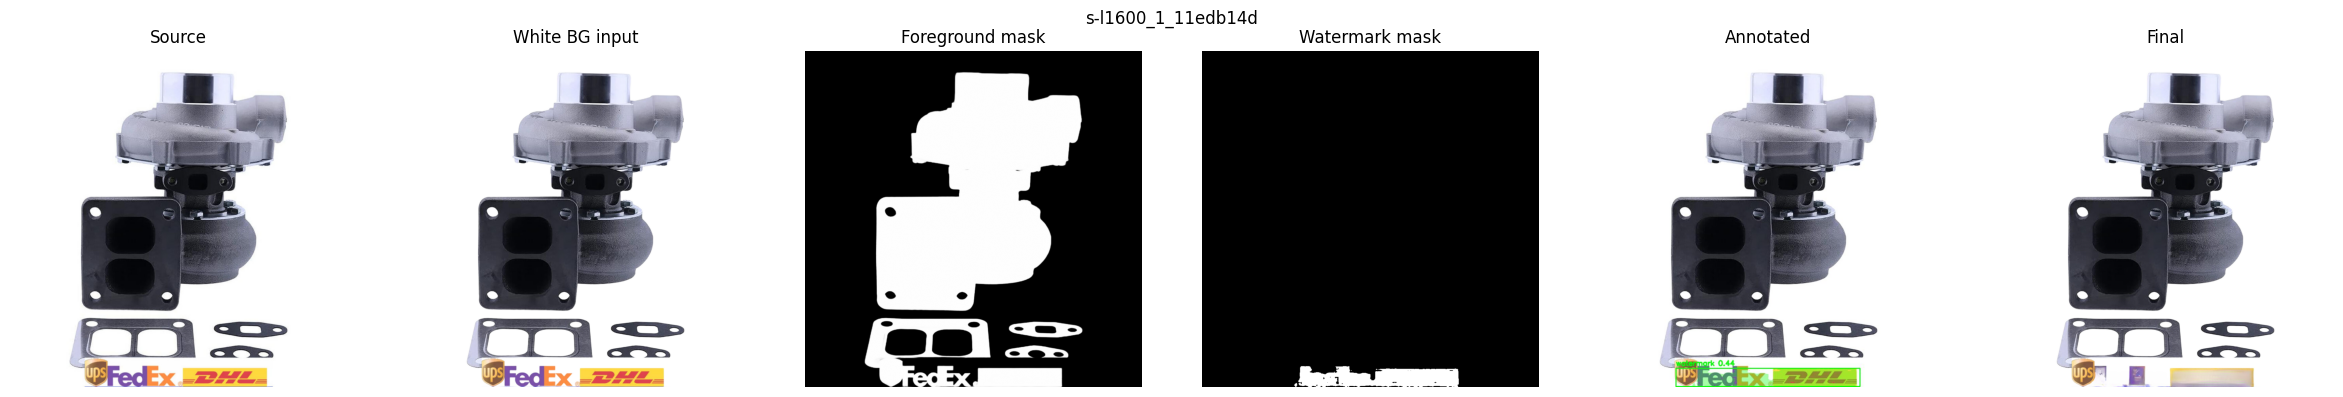

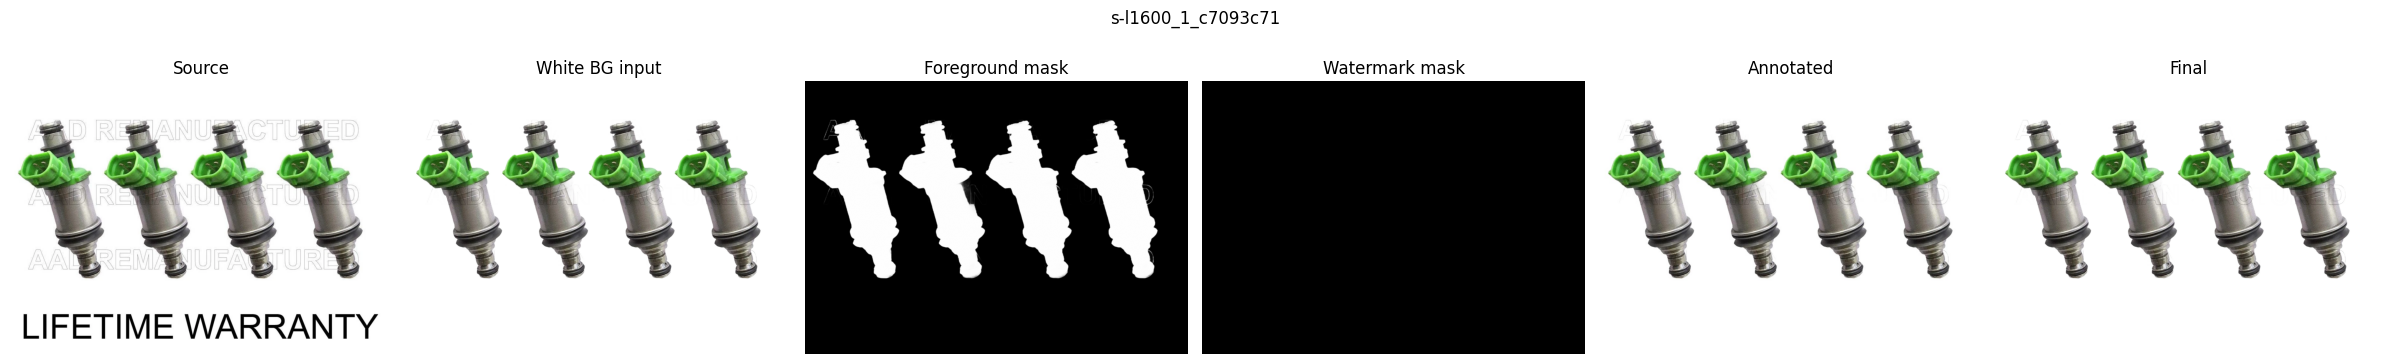

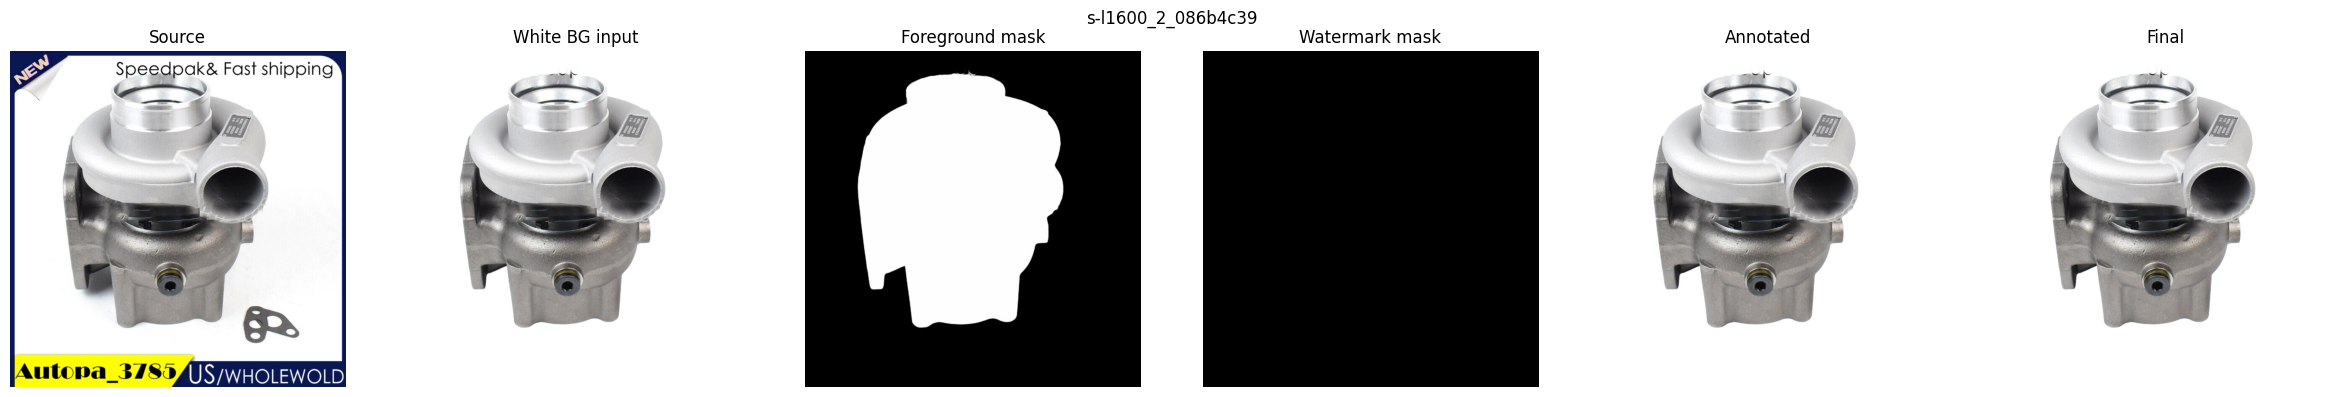

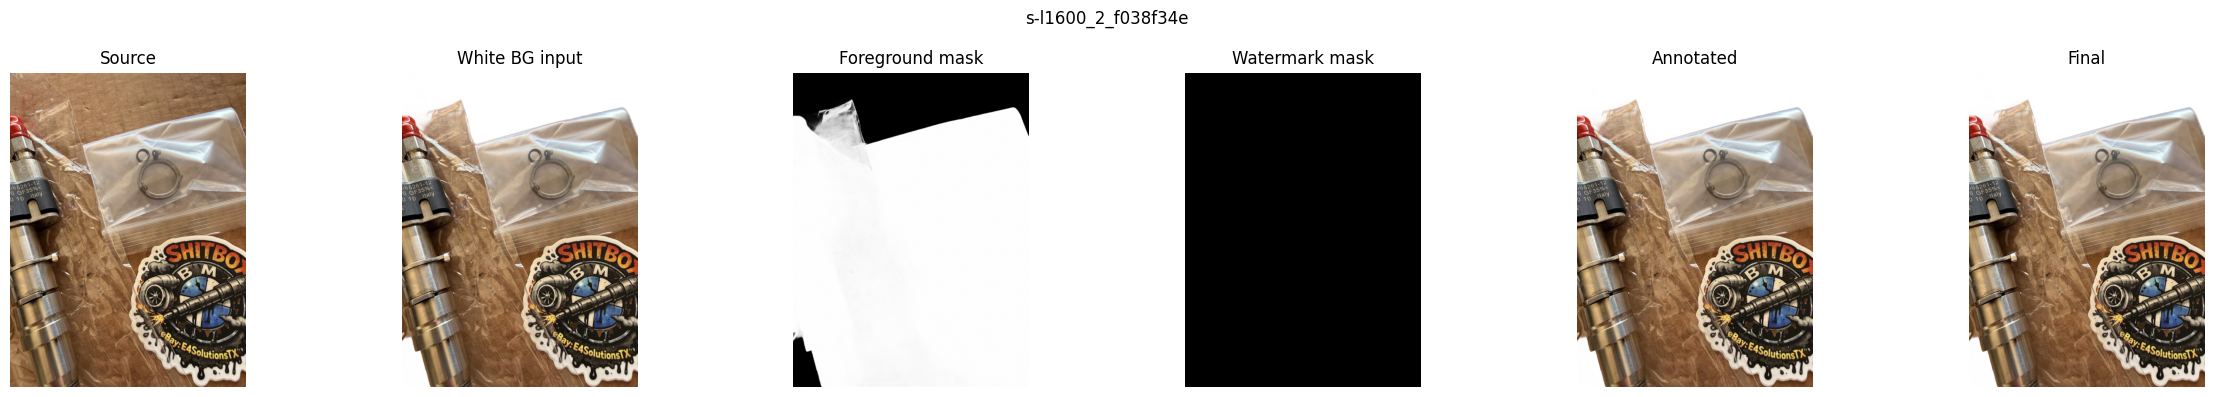

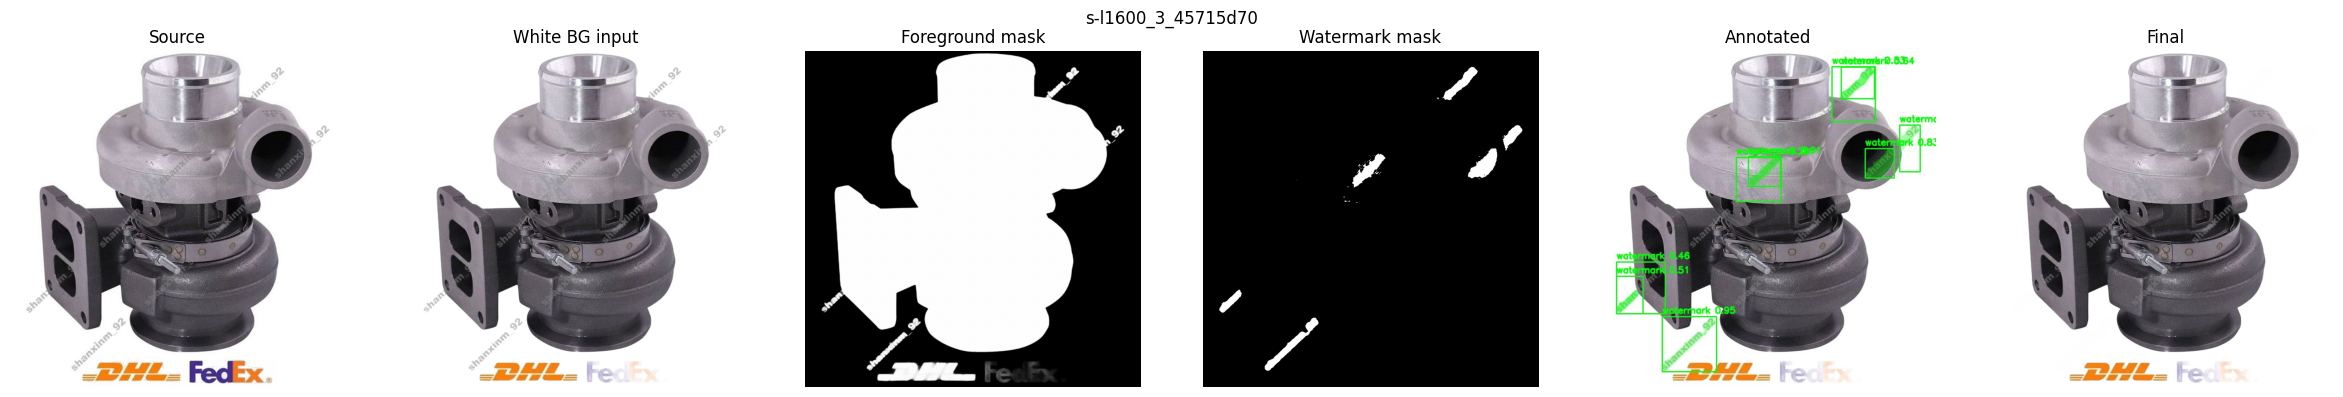

In [28]:
# @title 10. Preview results
import matplotlib.pyplot as plt


def preview_results(records, limit=5):
    preview_records = [record for record in records if not record.get("error")][:limit]
    if not preview_records:
        print("No successful records to preview.")
        return

    for record in preview_records:
        paths = [
            ("Source", record.get("source_original_path") or record.get("source_image_path")),
            ("White BG input", record.get("watermark_input_image_path")),
            ("Foreground mask", record.get("foreground_mask_path")),
            ("Watermark mask", record.get("combined_mask_path")),
            ("Annotated", record.get("annotated_image_path")),
            ("Final", record.get("final_image_path")),
        ]
        fig, axes = plt.subplots(1, len(paths), figsize=(4 * len(paths), 4))
        fig.suptitle(record["image_id"])

        for ax, (title, path) in zip(axes, paths):
            ax.set_title(title)
            ax.axis("off")
            if path and Path(path).exists():
                image = Image.open(path)
                if "mask" in title.lower():
                    ax.imshow(image.convert("L"), cmap="gray")
                else:
                    ax.imshow(image.convert("RGB"))
            else:
                ax.text(0.5, 0.5, "missing", ha="center", va="center")

        plt.tight_layout()
        plt.show()


preview_results(records, limit=5)
